In [1]:
import os
# Switch to parent directory
os.chdir("..")
root = os.getcwd()

In [2]:
import sys
sys.path.insert(0, os.path.join(root, "src"))

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from spo.models import (
    calibrate_gbm, calibrate_heston_multi,
    simulate_gbm_paths, simulate_heston_paths,
)
from spo.optim import (
    min_cvar_portfolio, min_var_portfolio,
    compute_cvar, cvar_frontier, scenarios_from_sim,
)
from spo.backtest import backtest, summary

log_ret = pd.read_parquet(root + "/data/processed/sp500_log_returns.parquet")
calibration_window = log_ret.iloc[-756:]
tickers = list(calibration_window.columns)

gbm = calibrate_gbm(calibration_window)
heston = calibrate_heston_multi(calibration_window)

# Simulate 21-day (1-month rebalance horizon) scenarios
sim_gbm = simulate_gbm_paths(gbm, n_paths=5000, n_steps=21, seed=42)
sim_hes = simulate_heston_paths(heston, n_paths=5000, n_steps=21, seed=42)

scen_gbm = scenarios_from_sim(sim_gbm, return_type="simple")
scen_hes = scenarios_from_sim(sim_hes, return_type="simple")

print(f"Scenarios shape (GBM): {scen_gbm.shape}")
print(f"Scenarios shape (Heston): {scen_hes.shape}")

Scenarios shape (GBM): (5000, 429)
Scenarios shape (Heston): (5000, 429)


In [4]:
# Min-CVaR on GBM scenarios
w_cvar_gbm = min_cvar_portfolio(scen_gbm, alpha=0.95, tickers=tickers)

# Min-Variance on GBM scenarios (via synthetic returns matching the cov)
# Cleaner: just call min-variance on the recent panel
w_mv = min_var_portfolio(calibration_window, covariance="ledoit_wolf")

# Side-by-side
weights_compare = pd.DataFrame({
    "Min-Var (historical)": w_mv,
    "Min-CVaR (GBM scen.)": w_cvar_gbm,
}).fillna(0)

print(f"L1 weight difference (Min-Var vs Min-CVaR-GBM): "
      f"{(w_mv - w_cvar_gbm).abs().sum():.4f}")

L1 weight difference (Min-Var vs Min-CVaR-GBM): 0.8939


In [5]:
w_cvar_hes = min_cvar_portfolio(scen_hes, alpha=0.95, tickers=tickers)

weights_compare = pd.DataFrame({
    "Min-Var": w_mv,
    "Min-CVaR (GBM)": w_cvar_gbm,
    "Min-CVaR (Heston)": w_cvar_hes,
}).fillna(0)

print(f"L1 (Min-Var vs CVaR-GBM): {(w_mv - w_cvar_gbm).abs().sum():.4f}")
print(f"L1 (Min-Var vs CVaR-Heston): {(w_mv - w_cvar_hes).abs().sum():.4f}")
print(f"L1 (CVaR-GBM vs CVaR-Heston): {(w_cvar_gbm - w_cvar_hes).abs().sum():.4f}")

L1 (Min-Var vs CVaR-GBM): 0.8939
L1 (Min-Var vs CVaR-Heston): 0.9055
L1 (CVaR-GBM vs CVaR-Heston): 0.4301


In [6]:
# Evaluate all three portfolios on the same Heston scenarios
results = []
for name, w in [("Min-Var", w_mv), ("Min-CVaR (GBM)", w_cvar_gbm),
                ("Min-CVaR (Heston)", w_cvar_hes)]:
    var, cvar = compute_cvar(scen_hes, w.reindex(tickers, fill_value=0).values, alpha=0.95)
    results.append({"Portfolio": name, "VaR_95": var, "CVaR_95": cvar})
pd.DataFrame(results).set_index("Portfolio").style.format("{:.4%}")

,VaR_95,CVaR_95
Portfolio,,
Min-Var,2.1647%,3.1545%
Min-CVaR (GBM),1.6062%,2.6463%
Min-CVaR (Heston),1.5650%,2.5086%


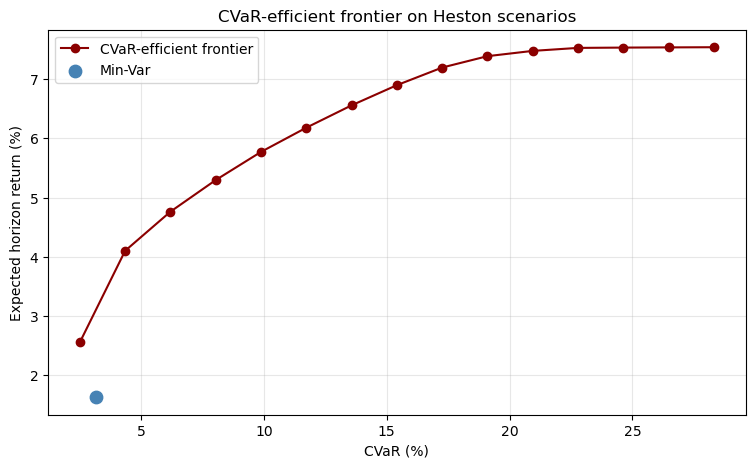

In [7]:
frontier = cvar_frontier(scen_hes, n_points=15, alpha=0.95, tickers=tickers)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(frontier["realized_cvar"] * 100, frontier["expected_return"] * 100,
        "-o", color="darkred", label="CVaR-efficient frontier")
ax.scatter([compute_cvar(scen_hes, w_mv.reindex(tickers, fill_value=0).values, 0.95)[1] * 100],
           [scen_hes.mean(axis=0) @ w_mv.reindex(tickers, fill_value=0).values * 100],
           color="steelblue", s=80, zorder=5, label="Min-Var")
ax.set_xlabel("CVaR (%)"); ax.set_ylabel("Expected horizon return (%)")
ax.set_title("CVaR-efficient frontier on Heston scenarios")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

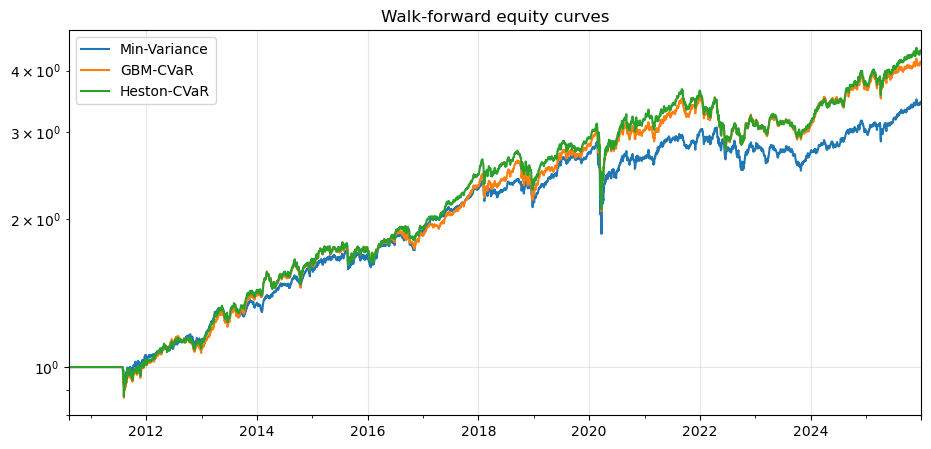

,Min-Variance,GBM-CVaR,Heston-CVaR
Ann. Returns,0.080753,0.093411,0.097060
Ann. Vol,0.119246,0.133207,0.133368
Sharpe,0.711404,0.737479,0.761800
Sortino,0.780354,0.838423,0.849685
Max DD,-0.350367,-0.323158,-0.330754
Calmar,0.230481,0.289056,0.293449


In [6]:
def mv_strategy(lookback):
    return min_var_portfolio(lookback, covariance="ledoit_wolf")

def gbm_cvar_strategy(lookback):
    p = calibrate_gbm(lookback)
    sim = simulate_gbm_paths(p, n_paths=3000, n_steps=21, seed=0)
    scen = scenarios_from_sim(sim, return_type="simple")
    return min_cvar_portfolio(scen, alpha=0.95, tickers=p.tickers)

def heston_cvar_strategy(lookback):
    h = calibrate_heston_multi(lookback)
    sim = simulate_heston_paths(h, n_paths=3000, n_steps=21, seed=0)
    scen = scenarios_from_sim(sim, return_type="simple")
    return min_cvar_portfolio(scen, alpha=0.95, tickers=h.tickers)

strategies = {
    "Min-Variance": mv_strategy,
    "GBM-CVaR": gbm_cvar_strategy,
    "Heston-CVaR": heston_cvar_strategy,
}

results = {
    name: backtest(log_ret, fn, rebalance_freq="BME",
                                lookback=504, cost=10.0)
    for name, fn in strategies.items()
}

fig, ax = plt.subplots(figsize=(11, 5))
for name, res in results.items():
    (1 + res["net_returns"]).cumprod().plot(ax=ax, label=name)
ax.set_yscale("log"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title("Walk-forward equity curves")
plt.show()

pd.concat({name: summary(res["net_returns"]) for name, res in results.items()}, axis=1)